In [1]:
# Seminar 2 - Setup and dataset upload

from google.colab import files
import zipfile
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Upload the dataset zip file
uploaded = files.upload()

# Get uploaded filename
zip_filename = list(uploaded.keys())[0]
print("Uploaded file:", zip_filename)

# Create folder for extracted dataset
dataset_folder = "Seminar2_dataset"
os.makedirs(dataset_folder, exist_ok=True)

# Extract zip file
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall(dataset_folder)

print("Dataset extracted to:", dataset_folder)

# Show extracted files
for root, dirs, files_in_dir in os.walk(dataset_folder):
    for file in files_in_dir:
        print(os.path.join(root, file))

Saving dataset_Seminar2.zip to dataset_Seminar2.zip
Uploaded file: dataset_Seminar2.zip
Dataset extracted to: Seminar2_dataset
Seminar2_dataset/Train_labels.csv
Seminar2_dataset/Train_features.csv
Seminar2_dataset/Test_features.csv
Seminar2_dataset/Test_labels.csv
Seminar2_dataset/Train_skelletonpoints.csv
Seminar2_dataset/Test_skelletonpoints.csv
Seminar2_dataset/__MACOSX/._Train_labels.csv
Seminar2_dataset/__MACOSX/._Test_skelletonpoints.csv
Seminar2_dataset/__MACOSX/._Test_labels.csv
Seminar2_dataset/__MACOSX/._Train_features.csv
Seminar2_dataset/__MACOSX/._Test_features.csv
Seminar2_dataset/__MACOSX/._Train_skelletonpoints.csv


The goal of this Collab Notebook and Seminar is to classify human poses using Wi-Fi Channel State Information (CSI) measurements instead of using images. Wi-Fi devices capture CSI and these measurements are affected by the different human poses.

We will analyze CSI data and train a SVM classifier to try to recognize th epose associated with each CSI sample

**PART 1 DATA PREPARATION & ANALYSIS**

**Inspect dataset shape**

In [2]:
# Subpart 1: Load the CSV files and inspect the dataset

import os
import pandas as pd
import numpy as np

# Locate CSV files
csv_files = {}

for root, dirs, files_in_dir in os.walk(dataset_folder):
    for file in files_in_dir:
        if file.endswith(".csv") and "__MACOSX" not in root:
            csv_files[file] = os.path.join(root, file)

print("CSV files found:")
for name, path in csv_files.items():
    print(f"{name}: {path}")

# Load datasets
train_features = pd.read_csv(csv_files["Train_features.csv"], header=None)
train_labels = pd.read_csv(csv_files["Train_labels.csv"], header=None)
test_features = pd.read_csv(csv_files["Test_features.csv"], header=None)
test_labels = pd.read_csv(csv_files["Test_labels.csv"], header=None)

train_skeleton = pd.read_csv(csv_files["Train_skelletonpoints.csv"], header=None)
test_skeleton = pd.read_csv(csv_files["Test_skelletonpoints.csv"], header=None)

# Print shapes
print("\nDataset shapes:")
print("Train features:", train_features.shape)
print("Train labels:", train_labels.shape)
print("Test features:", test_features.shape)
print("Test labels:", test_labels.shape)
print("Train skeleton points:", train_skeleton.shape)
print("Test skeleton points:", test_skeleton.shape)

# Show first rows
print("\nFirst training labels:")
print(train_labels.head())

CSV files found:
Train_labels.csv: Seminar2_dataset/Train_labels.csv
Train_features.csv: Seminar2_dataset/Train_features.csv
Test_features.csv: Seminar2_dataset/Test_features.csv
Test_labels.csv: Seminar2_dataset/Test_labels.csv
Train_skelletonpoints.csv: Seminar2_dataset/Train_skelletonpoints.csv
Test_skelletonpoints.csv: Seminar2_dataset/Test_skelletonpoints.csv

Dataset shapes:
Train features: (1000, 270)
Train labels: (1, 1000)
Test features: (200, 270)
Test labels: (1, 200)
Train skeleton points: (1000, 54)
Test skeleton points: (400, 54)

First training labels:
   0    1    2    3    4    5    6    7    8    9    ...  990  991  992  993  \
0    1    1    5    1    4    5    3    2    1    1  ...    3    1    4    1   

   994  995  996  997  998  999  
0    2    4    1    2    5    1  

[1 rows x 1000 columns]


In [3]:
# Subpart 2: Fix label dimensions and inspect classes

# Convert labels from shape (1, N) to (N,)
train_labels = train_labels.values.flatten()
test_labels = test_labels.values.flatten()

print("Corrected train labels shape:", train_labels.shape)
print("Corrected test labels shape:", test_labels.shape)

# Show unique classes
print("\nClasses in training set:")
print(np.unique(train_labels))

# Count samples per class
print("\nSamples per class (train):")

unique, counts = np.unique(train_labels, return_counts=True)

for label, count in zip(unique, counts):
    print(f"Class {label}: {count} samples")

Corrected train labels shape: (1000,)
Corrected test labels shape: (200,)

Classes in training set:
[1 2 3 4 5]

Samples per class (train):
Class 1: 169 samples
Class 2: 210 samples
Class 3: 174 samples
Class 4: 226 samples
Class 5: 221 samples


After these code cells we can see that the dataset conatins CSI measurements as input features, pose labels used as target classes and skeleton points used for visualization. The CSI values are stored as vectors of 270 values which  correspond to 30 subcarriers, 3 transmitter antennas as well as 3 rceiver antennas.

We transformed the dimensiion of the labels to be 1 dimension vector in order to work with the scikit-learn library.

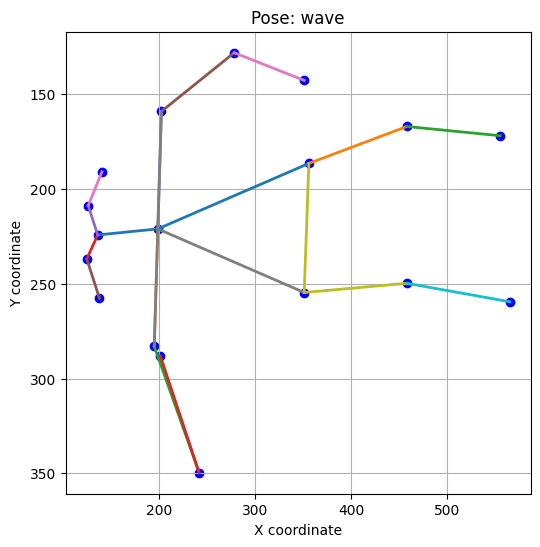

In [9]:
# Task 1: Plot SkeletonPoints and pose labels

# Mapping from class number to pose name
pose_names = {
    1: "wave",
    2: "push",
    3: "crouch",
    4: "sitdown",
    5: "bend"
}

# Body connections (We followed seminar slides conenections)
#Because Python uses 0-based indexing we subtract 1 from the slide indices

connections = [
    (0, 1),    # Nose -> Neck
    (1, 2),    # Neck -> Right Shoulder
    (2, 3),    # Right Shoulder -> Right Elbow
    (3, 4),    # Right Elbow -> Right Wrist
    (1, 5),    # Neck -> Left Shoulder
    (5, 6),    # Left Shoulder -> Left Elbow
    (6, 7),    # Left Elbow -> Left Wrist
    (1, 8),    # Neck -> Right Hip
    (8, 9),    # Right Hip -> Right Knee
    (9, 10),   # Right Knee -> Right Ankle
    (1, 11),   # Neck -> Left Hip
    (11, 12),  # Left Hip -> Left Knee
    (12, 13),  # Left Knee -> Left Ankle
    (0, 14),   # Nose -> Right Eye
    (0, 15),   # Nose -> Left Eye
    (14, 16),  # Right Eye -> Right Ear
    (15, 17),  # Left Eye -> Left Ear
    (2, 5),    # Right Shoulder -> Left Shoulder
    (8, 11),   # Right Hip -> Left Hip
]

# Function to plot a skeleton
def plot_skeleton(sample_index, skeleton_data, labels):

    sample = skeleton_data.iloc[sample_index].values

    # First 18 values -> x coordinates
    x = sample[:18]

    # Next 18 values -> y coordinates
    y = sample[18:36]

    # Pose label
    label = labels[sample_index]
    pose_name = pose_names[label]

    plt.figure(figsize=(6,6))

    # Plot body joints
    plt.scatter(x, y, color='blue')

    # Draw body connections
    for start, end in connections:
        plt.plot([x[start], x[end]],
                 [y[start], y[end]],
                 linewidth=2)

    plt.title(f"Pose: {pose_name}")
    plt.xlabel("X coordinate")
    plt.ylabel("Y coordinate")

    # Invert y-axis for human-like visualization
    plt.gca().invert_yaxis()

    plt.grid(True)
    plt.show()

# Plot an example skeleton
plot_skeleton(
    sample_index=0,
    skeleton_data=train_skeleton,
    labels=train_labels
)

This image is an example of the skeleton represetnation associated with one pose sample of the dataset. This visualization helps reconstruct the human posture associated with the CSI measurements and provides a better understanding of the pose classification problem.

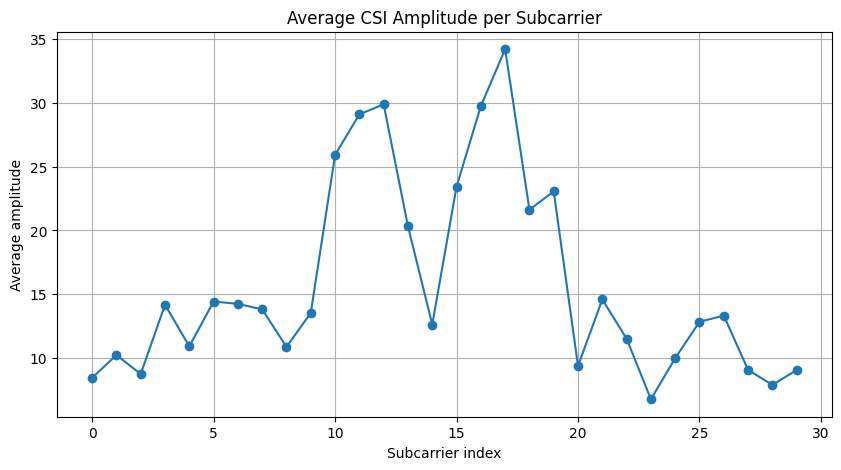

In [10]:
# Task 2: Plot average CSI amplitude per subcarrier

def plot_average_csi(sample_index, features):

    # Get one CSI sample
    sample = features.iloc[sample_index].values

    # Reshape from 270 -> (30 subcarriers, 3 TX, 3 RX)
    csi_matrix = sample.reshape(30, 3, 3)

    # Compute average amplitude for each subcarrier
    avg_amplitude = np.mean(np.abs(csi_matrix), axis=(1,2))

    # Plot
    plt.figure(figsize=(10,5))

    plt.plot(range(30), avg_amplitude, marker='o')

    plt.title("Average CSI Amplitude per Subcarrier")
    plt.xlabel("Subcarrier index")
    plt.ylabel("Average amplitude")

    plt.grid(True)
    plt.show()

# Plot one example
plot_average_csi(
    sample_index=0,
    features=train_features
)

This figure represents the average CSI amplitude for each one of the 30 subcarriers in one CSI sample. Their differences in channel amplitudes is because of the wireless propagation effects such as multipath, reflections, attenuation or body obstruction.

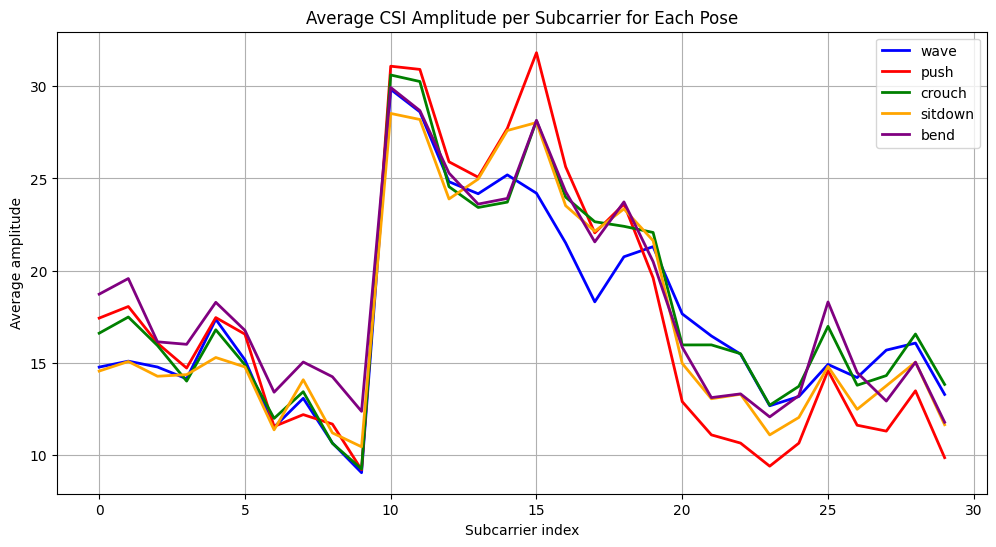

In [11]:
# Task 3: Plot CSI amplitude distributions for each class

# Colors for plotting
colors = ['blue', 'red', 'green', 'orange', 'purple']

plt.figure(figsize=(12,6))

# Iterate through each class
for i, class_id in enumerate(sorted(np.unique(train_labels))):

    # Select samples belonging to the class
    class_samples = train_features[train_labels == class_id]

    # Store average CSI amplitudes
    class_amplitudes = []

    # Process each sample
    for _, row in class_samples.iterrows():

        # Reshape into CSI matrix
        csi_matrix = row.values.reshape(30, 3, 3)

        # Compute average amplitude per subcarrier
        avg_amplitude = np.mean(np.abs(csi_matrix), axis=(1,2))

        class_amplitudes.append(avg_amplitude)

    # Average across all samples of the class
    class_mean = np.mean(class_amplitudes, axis=0)

    # Plot
    plt.plot(
        range(30),
        class_mean,
        label=pose_names[class_id],
        color=colors[i],
        linewidth=2
    )

# Final plot settings
plt.title("Average CSI Amplitude per Subcarrier for Each Pose")
plt.xlabel("Subcarrier index")
plt.ylabel("Average amplitude")

plt.legend()
plt.grid(True)
plt.show()

This figure compares the average CSI amplitude distributions for the different pose classe. Despite being quite similar, some variations can be observed in some subcarriers. These variations indicate that different human poses provoke distinct channel patternes.

**Part 2 - Model implementation**

In [12]:
# Task 4: Feature normalization and SVM training

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Normalize features
scaler = StandardScaler()

X_train = scaler.fit_transform(train_features)
X_test = scaler.transform(test_features)

# Create SVM classifier
svm_model = SVC(
    kernel='rbf',   # Radial Basis Function kernel
    C=1.0,
    gamma='scale'
)

# Train the model
svm_model.fit(X_train, train_labels)

print("SVM training completed.")

SVM training completed.


Test accuracy: 0.7700

Classification report:
              precision    recall  f1-score   support

        wave       0.84      0.76      0.80        42
        push       0.71      0.82      0.76        39
      crouch       0.78      0.89      0.83        35
     sitdown       0.84      0.68      0.75        38
        bend       0.72      0.72      0.72        46

    accuracy                           0.77       200
   macro avg       0.78      0.77      0.77       200
weighted avg       0.78      0.77      0.77       200



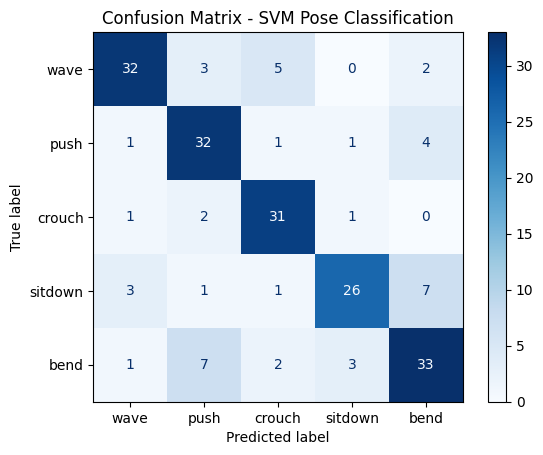

In [13]:
# Task 5: Generate predictions and evaluate the SVM

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Generate predictions
test_predictions = svm_model.predict(X_test)

# Compute accuracy
accuracy = accuracy_score(test_labels, test_predictions)

print(f"Test accuracy: {accuracy:.4f}")

# Detailed classification metrics
print("\nClassification report:")
print(classification_report(
    test_labels,
    test_predictions,
    target_names=list(pose_names.values())
))

# Confusion matrix
cm = confusion_matrix(test_labels, test_predictions)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=list(pose_names.values())
)

disp.plot(cmap='Blues')
plt.title("Confusion Matrix - SVM Pose Classification")
plt.show()

The SVM classifier achieved a test accuracy of 77%, indicating good performance. The confusion matrix shows that good model decisions, but some confusions exists between poses with similar body shape, such as sitdown and bend.

Overall, the results demonstrate that CSI measurements actually contain meaningful information about human posture.